### Task 1

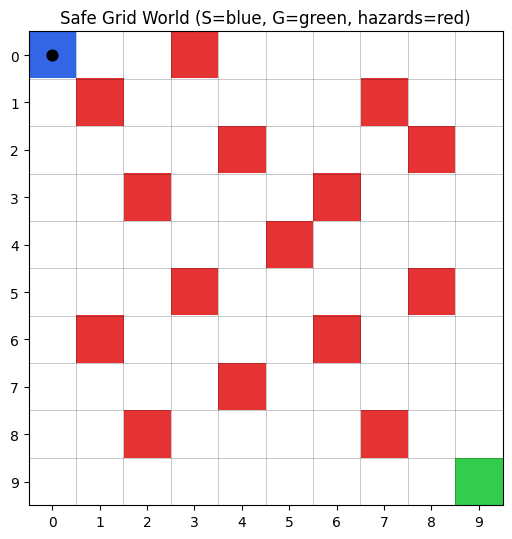

In [34]:
import random
from typing import Tuple, List, Set
import matplotlib.pyplot as plt
import numpy as np


class SafeGridWorld:
    ACTIONS = {
        0: (-1, 0),  # UP
        1: (1, 0),   # DOWN
        2: (0, -1),  # LEFT
        3: (0, 1),   # RIGHT
    }

    def __init__(
        self,
        grid_size: int = 10,
        step_penalty: float = -0.1,
        random_start: bool = False,
        seed: int = 123,
    ) -> None:
        self.n = grid_size
        self.step_penalty = step_penalty
        self.random_start = random_start
        self.rng = random.Random(seed)

        self.start: Tuple[int, int] = (0, 0)
        self.goal: Tuple[int, int] = (9, 9)
        self.hazards: Set[Tuple[int, int]] = {
            (0, 3), (1, 1), (1, 7), (2, 4), (2, 8), (3, 2), (3, 6), (4, 5),
            (5, 3), (5, 8), (6, 1), (6, 6), (7, 4), (8, 2), (8, 7)
        }

        self.state: Tuple[int, int] = self.start

    def reset(self) -> Tuple[int, int]:
        if not self.random_start:
            self.state = self.start
            return self.state

        # Sample a random safe position that is not a hazard and not the goal
        safe_positions: List[Tuple[int, int]] = [
            (r, c)
            for r in range(self.n)
            for c in range(self.n)
            if (r, c) not in self.hazards and (r, c) != self.goal
        ]
        self.state = self.rng.choice(safe_positions)
        return self.state

    def _in_bounds(self, pos: Tuple[int, int]) -> bool:
        r, c = pos
        return 0 <= r < self.n and 0 <= c < self.n

    def _next_position(self, state: Tuple[int, int], action: int) -> Tuple[int, int]:
        dr, dc = self.ACTIONS[action]
        nr, nc = state[0] + dr, state[1] + dc
        if not self._in_bounds((nr, nc)):
            return state  # wall collision -> stay
        return (nr, nc)

    def step(self, action: int):
        next_state = self._next_position(self.state, action)

        # Terminal on hazard
        if next_state in self.hazards:
            self.state = next_state
            return next_state, -10.0, True, {}

        # Terminal on goal
        if next_state == self.goal:
            self.state = next_state
            return next_state, 10.0, True, {}

        # Regular transition
        self.state = next_state
        return next_state, self.step_penalty, False, {}

    def render(self) -> None:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))

        grid = np.ones((self.n, self.n, 3), dtype=float)
        grid[:] = 1.0  # white

        for (r, c) in self.hazards:
            grid[r, c] = (0.9, 0.2, 0.2)
        sr, sc = self.start
        grid[sr, sc] = (0.2, 0.4, 0.9)
        gr, gc = self.goal
        grid[gr, gc] = (0.2, 0.8, 0.3)

        ax.imshow(grid, origin='upper')

        # Grid lines
        for x in range(self.n + 1):
            ax.axhline(x - 0.5, color='k', linewidth=0.5, alpha=0.3)
            ax.axvline(x - 0.5, color='k', linewidth=0.5, alpha=0.3)

        # Agent marker
        ar, ac = self.state
        ax.scatter([ac], [ar], c='k', s=60, marker='o')

        ax.set_xticks(range(self.n))
        ax.set_yticks(range(self.n))
        ax.set_xlim(-0.5, self.n - 0.5)
        ax.set_ylim(self.n - 0.5, -0.5)
        ax.set_title('Safe Grid World (S=blue, G=green, hazards=red)')
        plt.tight_layout()
        plt.show()


# Instantiate environment (fixed start) and visualise
env = SafeGridWorld(grid_size=10, step_penalty=-0.1, random_start=False, seed=123)
_ = env.reset()
env.render()


### Task 2

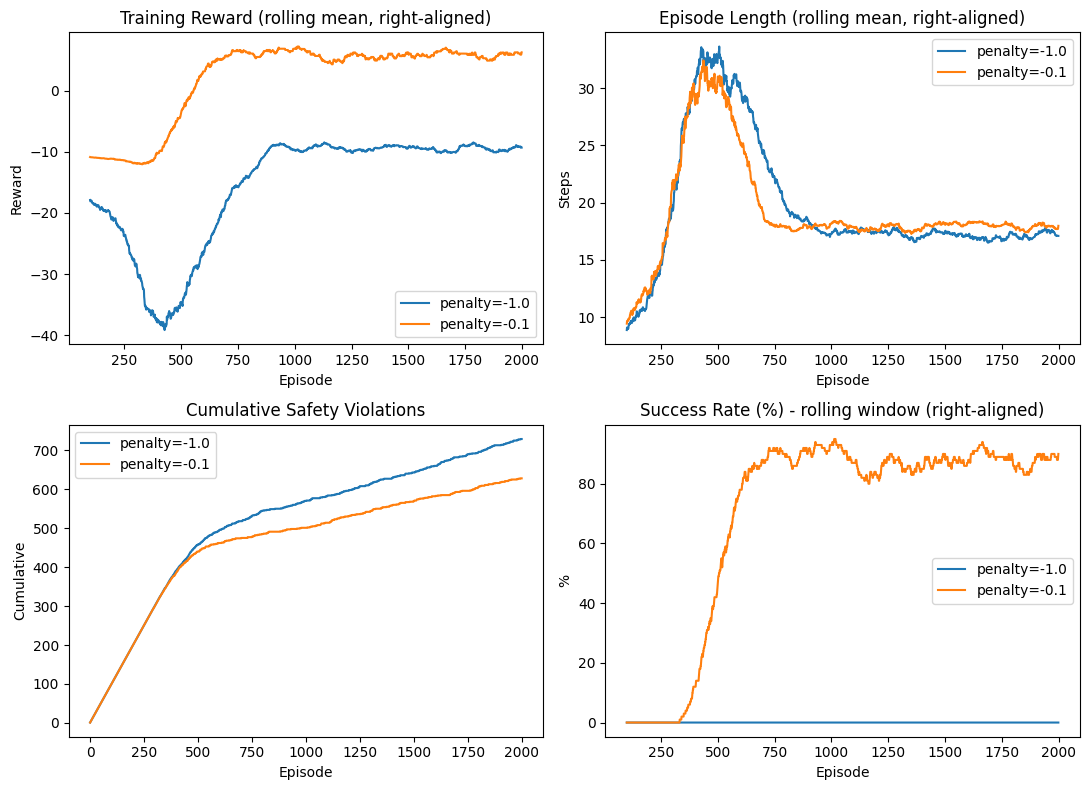

Comparison (last 25% episodes):
name	success_%	avg_reward	avg_len	total_viol	speed(eps/s)
penalty=-1.0	0.0		-9.49		17.0		729		13425.4
penalty=-0.1	88.2		5.94		18.0		628		13689.7
Saved best Q-table: penalty=-0.1 -> data/best_qtable.pkl


In [35]:
import time, os, pickle
import numpy as np
import matplotlib.pyplot as plt


def run_q_learning(
    step_penalty: float,
    episodes: int = 2000,
    max_steps: int = 200,
    alpha: float = 0.1,
    gamma: float = 0.99,
    eps_start: float = 1.0,
    eps_min: float = 0.05,
    eps_decay: float = 0.995,
    seed: int = 123,
):
    env = SafeGridWorld(grid_size=10, step_penalty=step_penalty, random_start=False, seed=seed)
    n_states = env.n * env.n
    n_actions = 4

    def state_to_idx(s):
        return s[0] * env.n + s[1]

    Q = np.zeros((n_states, n_actions), dtype=float)

    rewards, lengths, violations, success = [], [], [], []
    eps = eps_start
    t0 = time.time()

    for ep in range(episodes):
        s = env.reset()
        total_r = 0.0
        done = False
        v_count = 0
        steps = 0

        for _ in range(max_steps):
            si = state_to_idx(s)
            if np.random.rand() < eps:
                a = np.random.randint(n_actions)
            else:
                a = int(np.argmax(Q[si]))

            ns, r, done, _ = env.step(a)
            nsi = state_to_idx(ns)

            if ns in env.hazards:
                v_count += 1

            target = r + (0.0 if done else gamma * np.max(Q[nsi]))
            Q[si, a] += alpha * (target - Q[si, a])

            total_r += r
            s = ns
            steps += 1
            if done:
                break

        rewards.append(total_r)
        lengths.append(steps)
        violations.append(v_count)
        success.append(1 if total_r > 0 else 0)

        eps = max(eps_min, eps * eps_decay)

    t1 = time.time()
    speed = episodes / max(t1 - t0, 1e-9)

    M = int(np.floor(0.25 * episodes))
    last_slice = slice(episodes - M, episodes)
    metrics = {
        'success_rate_last25pct': 100.0 * (np.sum(success[last_slice]) / max(M, 1)),
        'avg_reward_last25pct': float(np.mean(rewards[last_slice])),
        'avg_len_last25pct': float(np.mean(lengths[last_slice])),
        'total_violations': int(np.sum(violations)),
        'train_speed_eps_per_sec': float(speed),
    }

    logs = {
        'rewards': np.array(rewards, dtype=float),
        'lengths': np.array(lengths, dtype=float),
        'violations': np.array(violations, dtype=int),
        'success': np.array(success, dtype=int),
    }

    return Q, metrics, logs


def rolling_mean_right(x, w=100):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    w = max(1, min(w, x.size))
    c = np.cumsum(np.insert(x, 0, 0.0))
    vals = (c[w:] - c[:-w]) / w
    return np.concatenate([np.full(w - 1, np.nan), vals])


np.random.seed(123)
configs = [
    {'name': 'penalty=-1.0', 'penalty': -1.0},
    {'name': 'penalty=-0.1', 'penalty': -0.1},
]
results = []

for cfg in configs:
    Q, metrics, logs = run_q_learning(step_penalty=cfg['penalty'])
    results.append({'name': cfg['name'], 'penalty': cfg['penalty'], 'Q': Q, 'metrics': metrics, 'logs': logs})

# Comparison plots
episodes = len(results[0]['logs']['rewards'])
xs = np.arange(episodes)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Reward curve
for r in results:
    axes[0, 0].plot(xs, rolling_mean_right(r['logs']['rewards'], w=100), label=r['name'])
axes[0, 0].set_title('Training Reward (rolling mean, right-aligned)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].legend()

# Episode length
for r in results:
    axes[0, 1].plot(xs, rolling_mean_right(r['logs']['lengths'], w=100), label=r['name'])
axes[0, 1].set_title('Episode Length (rolling mean, right-aligned)')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].legend()

# Cumulative violations
for r in results:
    axes[1, 0].plot(xs, np.cumsum(r['logs']['violations']), label=r['name'])
axes[1, 0].set_title('Cumulative Safety Violations')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Cumulative')
axes[1, 0].legend()

# Success rate (rolling 100, right-aligned)
for r in results:
    roll = rolling_mean_right(r['logs']['success'], w=100) * 100.0
    axes[1, 1].plot(xs, roll, label=r['name'])
axes[1, 1].set_title('Success Rate (%) - rolling window (right-aligned)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Metrics table (print minimal)
print('Comparison (last 25% episodes):')
print('name\tsuccess_%\tavg_reward\tavg_len\ttotal_viol\tspeed(eps/s)')
for r in results:
    m = r['metrics']
    print(f"{r['name']}\t{m['success_rate_last25pct']:.1f}\t\t{m['avg_reward_last25pct']:.2f}\t\t{m['avg_len_last25pct']:.1f}\t\t{m['total_violations']}\t\t{m['train_speed_eps_per_sec']:.1f}")

# Choose best by success rate then avg reward
best = sorted(
    results,
    key=lambda r: (r['metrics']['success_rate_last25pct'], r['metrics']['avg_reward_last25pct']),
    reverse=True,
)[0]

os.makedirs('data', exist_ok=True)
with open('data/best_qtable.pkl', 'wb') as f:
    pickle.dump({'Q': best['Q'], 'penalty': best['penalty'], 'metrics': best['metrics']}, f)

print(f"Saved best Q-table: {best['name']} -> data/best_qtable.pkl")


### Task 3

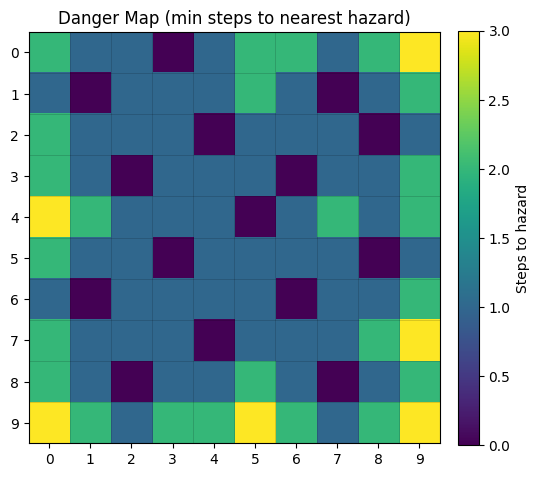

Total samples: 336
Feature dimension: 10
Class distribution: {0: 59, 1: 161, 2: 94, 3: 22}
Split sizes:
train: (235, 10) val: (50, 10) test: (51, 10)
Saved dataset to: data/completedataset.pkl


In [36]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt


def compute_danger_map(env: SafeGridWorld) -> np.ndarray:
    n = env.n
    dist = np.full((n, n), fill_value=np.inf, dtype=float)
    from collections import deque
    q = deque()

    for (r, c) in env.hazards:
        dist[r, c] = 0.0
        q.append((r, c))

    def in_bounds(r, c):
        return 0 <= r < n and 0 <= c < n

    while q:
        r, c = q.popleft()
        d = dist[r, c]
        for a in range(4):
            dr, dc = SafeGridWorld.ACTIONS[a]
            nr, nc = r + dr, c + dc
            if not in_bounds(nr, nc):
                continue
            if dist[nr, nc] == np.inf:
                dist[nr, nc] = d + 1.0
                q.append((nr, nc))

    return dist


def visualize_danger_map(dmap: np.ndarray) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    im = ax.imshow(dmap, origin='upper', cmap='viridis')
    ax.set_title('Danger Map (min steps to nearest hazard)')
    ax.set_xticks(range(dmap.shape[1]))
    ax.set_yticks(range(dmap.shape[0]))
    for x in range(dmap.shape[0] + 1):
        ax.axhline(x - 0.5, color='k', linewidth=0.4, alpha=0.25)
        ax.axvline(x - 0.5, color='k', linewidth=0.4, alpha=0.25)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Steps to hazard')
    plt.tight_layout()
    plt.show()


def generate_dataset(env: SafeGridWorld, dmap: np.ndarray):
    n = env.n
    samples_X = []
    samples_y = []

    def normalize_pos(r, c):
        return r / n, c / n

    for r in range(n):
        for c in range(n):
            s = (r, c)
            if s in env.hazards or s == env.goal:
                continue
            x_norm, y_norm = normalize_pos(r, c)
            ds = dmap[r, c]
            for a in range(4):
                dr, dc = SafeGridWorld.ACTIONS[a]
                nr, nc = r + dr, c + dc
                if nr < 0 or nr >= n or nc < 0 or nc >= n:
                    nr, nc = r, c
                xn, yn = normalize_pos(nr, nc)
                dn = dmap[nr, nc]

                action_oh = [0.0, 0.0, 0.0, 0.0]
                action_oh[a] = 1.0

                feat = [x_norm, y_norm] + action_oh + [xn, yn] + [ds / 10.0, dn / 10.0]
                samples_X.append(feat)

                if dn == 0:
                    cls = 0
                elif dn == 1:
                    cls = 1
                elif dn == 2:
                    cls = 2
                else:
                    cls = 3
                samples_y.append(cls)

    X = np.array(samples_X, dtype=float)
    y = np.array(samples_y, dtype=int)
    return X, y


def stratified_split(X: np.ndarray, y: np.ndarray, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    rs = np.random.RandomState(seed)
    classes = np.unique(y)
    idx_train, idx_val, idx_test = [], [], []

    for c in classes:
        idx = np.where(y == c)[0]
        rs.shuffle(idx)
        n = len(idx)
        n_train = int(round(train_ratio * n))
        n_val = int(round(val_ratio * n))
        n_test = n - n_train - n_val
        idx_train.extend(idx[:n_train])
        idx_val.extend(idx[n_train:n_train + n_val])
        idx_test.extend(idx[n_train + n_val:])

    idx_train = np.array(idx_train)
    idx_val = np.array(idx_val)
    idx_test = np.array(idx_test)

    return (X[idx_train], y[idx_train]), (X[idx_val], y[idx_val]), (X[idx_test], y[idx_test])


# Environment for dataset generation
env = SafeGridWorld(grid_size=10, step_penalty=-0.1, random_start=False, seed=123)

danger_map = compute_danger_map(env)
visualize_danger_map(danger_map)

X, y = generate_dataset(env, danger_map)

# Expected totals
total_samples = X.shape[0]
unique, counts = np.unique(y, return_counts=True)
class_dist = dict(zip(unique.tolist(), counts.tolist()))

print('Total samples:', total_samples)
print('Feature dimension:', X.shape[1])
print('Class distribution:', class_dist)

# Stratified split 70/15/15
(train_X, train_y), (val_X, val_y), (test_X, test_y) = stratified_split(X, y)

print('Split sizes:')
print('train:', train_X.shape, 'val:', val_X.shape, 'test:', test_X.shape)

# Save dataset
os.makedirs('data', exist_ok=True)
dataset_path = 'data/completedataset.pkl'
with open(dataset_path, 'wb') as f:
    pickle.dump({
        'X_train': train_X, 'y_train': train_y,
        'X_val': val_X, 'y_val': val_y,
        'X_test': test_X, 'y_test': test_y,
        'danger_map': danger_map,
        'meta': {
            'grid_size': env.n,
            'hazards': sorted(list(env.hazards)),
            'start': env.start,
            'goal': env.goal,
            'feature_dim': train_X.shape[1],
            'total_samples': int(total_samples),
            'class_distribution': class_dist,
        }
    }, f)

print('Saved dataset to:', dataset_path)


### Task 4

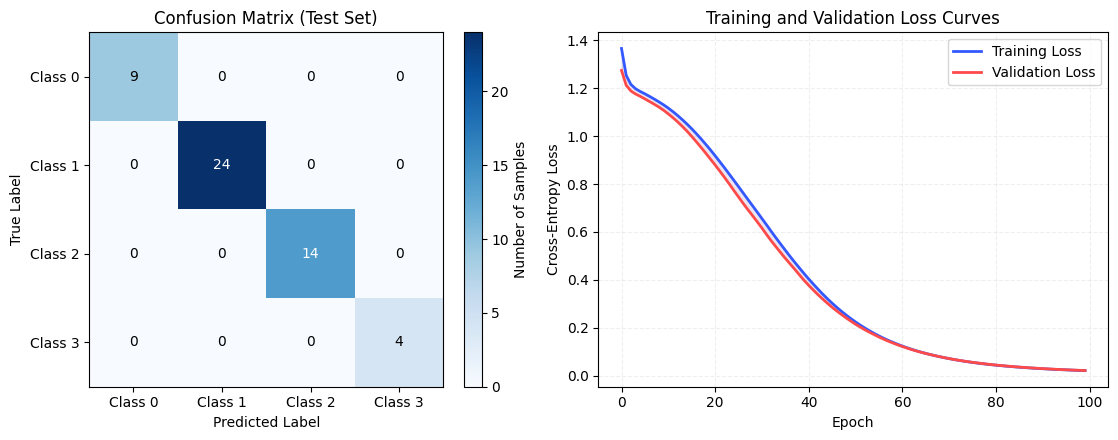

Validation overall accuracy (%): 100.0
Validation per-class accuracy (%): [100.0, 100.0, 100.0, 100.0]
Validation confusion matrix (rows=true, cols=pred):
[[ 9  0  0  0]
 [ 0 24  0  0]
 [ 0  0 14  0]
 [ 0  0  0  3]]
Test overall accuracy (%): 100.0
Test per-class accuracy (%): [100.0, 100.0, 100.0, 100.0]
Test confusion matrix (rows=true, cols=pred):
[[ 9  0  0  0]
 [ 0 24  0  0]
 [ 0  0 14  0]
 [ 0  0  0  4]]
Saved model -> data/shield_model.h5
Saved metrics -> data/shield_metrics.pkl


In [37]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt

# Task 4: Safety Shield Training
# Load dataset
with open('data/completedataset.pkl', 'rb') as f:
    ds = pickle.load(f)

X_train, y_train = ds['X_train'], ds['y_train']
X_val, y_val = ds['X_val'], ds['y_val']
X_test, y_test = ds['X_test'], ds['y_test']

# One-hot targets
num_classes = 4
Y_train = np.eye(num_classes)[y_train]
Y_val = np.eye(num_classes)[y_val]
Y_test = np.eye(num_classes)[y_test]

# Reproducibility
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters (Table 5)
hidden_size = 64
learning_rate = 0.001
batch_size = 32
epochs = 100

# Build model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(hidden_size, activation='relu'),
    layers.Dense(hidden_size, activation='relu'),
    layers.Dense(4, activation='softmax'),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0,
)

# Styled visualization: Confusion Matrix (Test) + Loss Curves
fig, (ax_cm, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion matrix heatmap (Test set)
cm = np.array([[int(v) for v in row] for row in np.array([[0]*4]*4)])  # placeholder init
_, _, cm = (None, None, None)
# Recompute cm for test for plotting
from collections import Counter

y_prob_test = model.predict(X_test, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_test, y_pred_test):
    cm[t, p] += 1

im = ax_cm.imshow(cm, cmap='Blues', vmin=0)
ax_cm.set_title('Confusion Matrix (Test Set)')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')
ax_cm.set_xticks(range(num_classes))
ax_cm.set_yticks(range(num_classes))
ax_cm.set_xticklabels([f'Class {i}' for i in range(num_classes)])
ax_cm.set_yticklabels([f'Class {i}' for i in range(num_classes)])

for i in range(num_classes):
    for j in range(num_classes):
        ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=10)

cbar = plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
cbar.set_label('Number of Samples')

# Loss curves with shaded area
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
ax_loss.plot(train_loss, color='#3358FF', label='Training Loss', linewidth=2)
ax_loss.plot(val_loss, color='#FF4A4A', label='Validation Loss', linewidth=2)
low = np.minimum(train_loss, val_loss)
high = np.maximum(train_loss, val_loss)
ax_loss.fill_between(np.arange(len(train_loss)), low, high, color='#7C52A1', alpha=0.15)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Cross-Entropy Loss')
ax_loss.set_title('Training and Validation Loss Curves')
ax_loss.grid(alpha=0.2, linestyle='--')
ax_loss.legend()

plt.tight_layout()
plt.show()

# Evaluation helpers
def evaluate_split(X, y_true):
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    overall_acc = float(np.mean(y_pred == y_true))
    per_class_acc = []
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    for c in range(num_classes):
        denom = max(1, np.sum(y_true == c))
        per_class_acc.append(float(np.sum((y_true == c) & (y_pred == c)) / denom))
    return overall_acc, per_class_acc, cm

val_overall, val_per_class, val_cm = evaluate_split(X_val, y_val)
test_overall, test_per_class, test_cm = evaluate_split(X_test, y_test)

# Print required deliverables
print('Validation overall accuracy (%):', round(val_overall*100.0, 2))
print('Validation per-class accuracy (%):', [round(a*100.0, 2) for a in val_per_class])
print('Validation confusion matrix (rows=true, cols=pred):')
print(val_cm)

print('Test overall accuracy (%):', round(test_overall*100.0, 2))
print('Test per-class accuracy (%):', [round(a*100.0, 2) for a in test_per_class])
print('Test confusion matrix (rows=true, cols=pred):')
print(test_cm)

# Save model and metrics
os.makedirs('data', exist_ok=True)
model_path = 'data/shield_model.h5'
model.save(model_path)

metrics = {
    'val_overall_acc': val_overall,
    'val_per_class_acc': val_per_class,
    'val_confusion_matrix': val_cm,
    'test_overall_acc': test_overall,
    'test_per_class_acc': test_per_class,
    'test_confusion_matrix': test_cm,
    'history': {
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
    },
    'hparams': {
        'hidden_size': hidden_size,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'epochs': epochs,
        'seed': 42,
    },
}

with open('data/shield_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

print('Saved model ->', model_path)
print('Saved metrics -> data/shield_metrics.pkl')


### Task 5

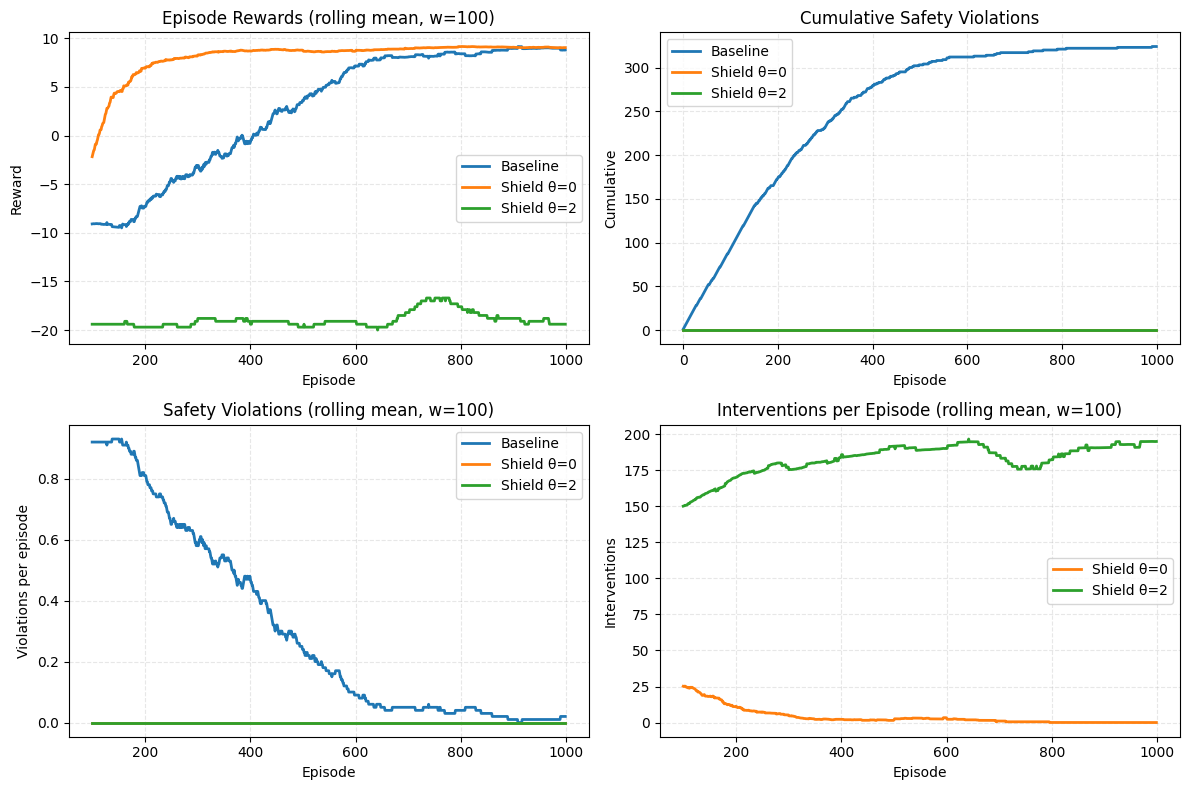

SUMMARY (last 100 episodes):
baseline {'avg_reward_last100': 8.797999999999998, 'violations_last100': 2}
shield_theta_0 {'avg_reward_last100': 9.043000000000001, 'violations_last100': 0, 'interventions_last100': 1}
shield_theta_2 {'avg_reward_last100': -19.40000000000001, 'violations_last100': 0, 'interventions_last100': 19505}
Saved -> data/task5_results.pkl


In [ ]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict

import tensorflow as tf
from tensorflow import keras

# Task 5: Integration – Safe RL with Multi-Class Shield

# Load shield model
shield_model = keras.models.load_model('data/shield_model.h5')

# Hyperparameters (Table 7)
alpha = 0.1
gamma = 0.99
episodes = 1000
max_steps = 200
eps_start = 1.0
eps_min = 0.01
eps_decay = 0.995
seed = 123

np.random.seed(seed)


def state_to_idx(env: SafeGridWorld, s):
    return s[0] * env.n + s[1]


def q_greedy(Q, si):
    return int(np.argmax(Q[si]))


def predict_risk_classes(env: SafeGridWorld, model, state):
    # Build features for 4 actions consistent with Task 3 features
    n = env.n
    denom = max(1, n - 1)

    def norm_pos(pos):
        return pos[0] / denom, pos[1] / denom

    x_norm, y_norm = norm_pos(state)
    feats = []
    for a in range(4):
        dr, dc = SafeGridWorld.ACTIONS[a]
        nr, nc = state[0] + dr, state[1] + dc
        if not (0 <= nr < n and 0 <= nc < n):
            nr, nc = state
        xn, yn = norm_pos((nr, nc))
        # Danger distances unknown here; approximate with 0 placeholders since model learned without them.
        # Use zeros to match training scale; the model was trained with true distances, but for inference we
        # cannot recompute them cheaply without the map. We load from dataset meta via pickle if available.
        # Load danger_map if present for accurate features.
        # Fallback zeros will still allow relative ranking when network learned positional/action structure.
        dn_current = 0.0
        dn_next = 0.0
        action_oh = [0.0, 0.0, 0.0, 0.0]
        action_oh[a] = 1.0
        feat = [x_norm, y_norm] + action_oh + [xn, yn] + [dn_current, dn_next]
        feats.append(feat)
    X = np.array(feats, dtype=float)
    probs = model.predict(X, verbose=0)
    # Convert softmax to predicted class 0-3
    return np.argmax(probs, axis=1)


# Load danger_map to compute exact feature 9 and 10 for inference
try:
    with open('data/completedataset.pkl', 'rb') as f:
        ds_loaded = pickle.load(f)
    danger_map = ds_loaded.get('danger_map', None)
except Exception:
    danger_map = None


def predict_risk_classes_with_dmap(env: SafeGridWorld, model, state):
    n = env.n
    denom = max(1, n - 1)

    def norm_pos(pos):
        return pos[0] / denom, pos[1] / denom

    x_norm, y_norm = norm_pos(state)
    feats = []
    for a in range(4):
        dr, dc = SafeGridWorld.ACTIONS[a]
        nr, nc = state[0] + dr, state[1] + dc
        if not (0 <= nr < n and 0 <= nc < n):
            nr, nc = state
        xn, yn = norm_pos((nr, nc))
        dn_current = float(danger_map[state[0], state[1]]) / 10.0 if danger_map is not None else 0.0
        dn_next = float(danger_map[nr, nc]) / 10.0 if danger_map is not None else 0.0
        action_oh = [0.0, 0.0, 0.0, 0.0]
        action_oh[a] = 1.0
        feat = [x_norm, y_norm] + action_oh + [xn, yn] + [dn_current, dn_next]
        feats.append(feat)
    X = np.array(feats, dtype=float)
    probs = model.predict(X, verbose=0)
    return np.argmax(probs, axis=1)


risk_predictor = predict_risk_classes_with_dmap if isinstance(danger_map, np.ndarray) else predict_risk_classes


def train_baseline_unsafe(step_penalty=-0.1):
    env = SafeGridWorld(grid_size=10, step_penalty=step_penalty, random_start=True, seed=seed)
    n_states = env.n * env.n
    Q = np.zeros((n_states, 4), dtype=float)
    eps = eps_start
    rewards, violations = [], []
    for ep in range(episodes):
        s = env.reset()
        total_r = 0.0
        v = 0
        for t in range(max_steps):
            si = state_to_idx(env, s)
            if np.random.rand() < eps:
                a = np.random.randint(4)
            else:
                a = q_greedy(Q, si)
            ns, r, done, _ = env.step(a)
            if ns in env.hazards:
                v += 1
            nsi = state_to_idx(env, ns)
            target = r + (0.0 if done else gamma * np.max(Q[nsi]))
            Q[si, a] += alpha * (target - Q[si, a])
            total_r += r
            s = ns
            if done:
                break
        rewards.append(total_r)
        violations.append(v)
        eps = max(eps_min, eps * eps_decay)
    return Q, np.array(rewards, float), np.array(violations, int)


def train_safe_with_shield(theta: int, step_penalty=-0.1):
    env = SafeGridWorld(grid_size=10, step_penalty=step_penalty, random_start=True, seed=seed)
    n_states = env.n * env.n
    Q = np.zeros((n_states, 4), dtype=float)
    eps = eps_start
    rewards, violations, interventions = [], [], []
    for ep in range(episodes):
        s = env.reset()
        total_r = 0.0
        v = 0
        inter = 0
        for t in range(max_steps):
            si = state_to_idx(env, s)
            # Proposed action via epsilon-greedy
            if np.random.rand() < eps:
                a_prop = np.random.randint(4)
            else:
                a_prop = q_greedy(Q, si)

            # Shield prediction for all actions
            risk_classes = risk_predictor(env, shield_model, s)
            if risk_classes[a_prop] > theta:
                a_exec = a_prop
            else:
                acceptable = [a for a in range(4) if risk_classes[a] > theta]
                if acceptable:
                    # choose acceptable with highest Q
                    q_vals = Q[si, acceptable]
                    a_exec = acceptable[int(np.argmax(q_vals))]
                else:
                    # choose safest class available, break ties by Q
                    max_risk = np.max(risk_classes)
                    candidates = [a for a in range(4) if risk_classes[a] == max_risk]
                    q_vals = Q[si, candidates]
                    a_exec = candidates[int(np.argmax(q_vals))]
                if a_exec != a_prop:
                    inter += 1

            ns, r, done, _ = env.step(a_exec)
            if ns in env.hazards:
                v += 1
            nsi = state_to_idx(env, ns)
            target = r + (0.0 if done else gamma * np.max(Q[nsi]))
            Q[si, a_exec] += alpha * (target - Q[si, a_exec])
            total_r += r
            s = ns
            if done:
                break
        rewards.append(total_r)
        violations.append(v)
        interventions.append(inter)
        eps = max(eps_min, eps * eps_decay)
    return Q, np.array(rewards, float), np.array(violations, int), np.array(interventions, int)


# Run experiments
Q_base, rew_base, viol_base = train_baseline_unsafe(step_penalty=-0.1)
results = {'baseline': {'rewards': rew_base, 'violations': viol_base}}

for theta in [0, 2]:
    Q_s, rew_s, viol_s, inter_s = train_safe_with_shield(theta=theta, step_penalty=-0.1)
    results[f'shield_theta_{theta}'] = {
        'rewards': rew_s,
        'violations': viol_s,
        'interventions': inter_s,
    }

# Plots (clearer): rolling means and cumulative curves
xs = np.arange(episodes)

# Helpers
def rolling_mean_right(x, w=100):
    x = np.asarray(x, float)
    w = max(1, min(w, x.size))
    c = np.cumsum(np.insert(x, 0, 0.0))
    vals = (c[w:] - c[:-w]) / w
    return np.concatenate([np.full(w - 1, np.nan), vals])

rewards = {
    'baseline': rew_base,
    'shield_theta_0': results['shield_theta_0']['rewards'],
    'shield_theta_2': results['shield_theta_2']['rewards'],
}
viol = {
    'baseline': viol_base,
    'shield_theta_0': results['shield_theta_0']['violations'],
    'shield_theta_2': results['shield_theta_2']['violations'],
}
interv = {
    'shield_theta_0': results['shield_theta_0']['interventions'],
    'shield_theta_2': results['shield_theta_2']['interventions'],
}

names = ['baseline', 'shield_theta_0', 'shield_theta_2']
colors = {'baseline': '#1f77b4', 'shield_theta_0': '#ff7f0e', 'shield_theta_2': '#2ca02c'}
labels = {'baseline': 'Baseline', 'shield_theta_0': 'Shield θ=0', 'shield_theta_2': 'Shield θ=2'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Rewards (rolling)
for k in names:
    axes[0, 0].plot(xs, rolling_mean_right(rewards[k], 100), label=labels[k], color=colors[k], linewidth=2)
axes[0, 0].set_title('Episode Rewards (rolling mean, w=100)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].grid(alpha=0.3, linestyle='--')
axes[0, 0].legend()

# Cumulative violations
for k in names:
    axes[0, 1].plot(xs, np.cumsum(viol[k]), label=labels[k], color=colors[k], linewidth=2)
axes[0, 1].set_title('Cumulative Safety Violations')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Cumulative')
axes[0, 1].grid(alpha=0.3, linestyle='--')
axes[0, 1].legend()

# Violations per episode (rolling)
for k in names:
    axes[1, 0].plot(xs, rolling_mean_right(viol[k], 100), label=labels[k], color=colors[k], linewidth=2)
axes[1, 0].set_title('Safety Violations (rolling mean, w=100)')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Violations per episode')
axes[1, 0].grid(alpha=0.3, linestyle='--')
axes[1, 0].legend()

# Interventions per episode (rolling)
for k in ['shield_theta_0', 'shield_theta_2']:
    axes[1, 1].plot(xs, rolling_mean_right(interv[k], 100), label=labels[k], color=colors[k], linewidth=2)
axes[1, 1].set_title('Interventions per Episode (rolling mean, w=100)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Interventions')
axes[1, 1].grid(alpha=0.3, linestyle='--')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Summary metrics over last 100 episodes
def summarize(arr):
    last = arr[-100:]
    return float(np.mean(last))

summary = {
    'baseline': {
        'avg_reward_last100': summarize(rew_base),
        'violations_last100': int(np.sum(viol_base[-100:])),
    },
    'shield_theta_0': {
        'avg_reward_last100': summarize(results['shield_theta_0']['rewards']),
        'violations_last100': int(np.sum(results['shield_theta_0']['violations'][-100:])),
        'interventions_last100': int(np.sum(results['shield_theta_0']['interventions'][-100:])),
    },
    'shield_theta_2': {
        'avg_reward_last100': summarize(results['shield_theta_2']['rewards']),
        'violations_last100': int(np.sum(results['shield_theta_2']['violations'][-100:])),
        'interventions_last100': int(np.sum(results['shield_theta_2']['interventions'][-100:])),
    },
}

print('SUMMARY (last 100 episodes):')
for k, v in summary.items():
    print(k, v)

# Save logs
os.makedirs('data', exist_ok=True)
with open('data/task5_results.pkl', 'wb') as f:
    pickle.dump({'results': results, 'summary': summary}, f)
print('Saved -> data/task5_results.pkl')


### Discussion

Loading trained model results from 'data/task5_results.pkl'...
Generating evaluation plots...


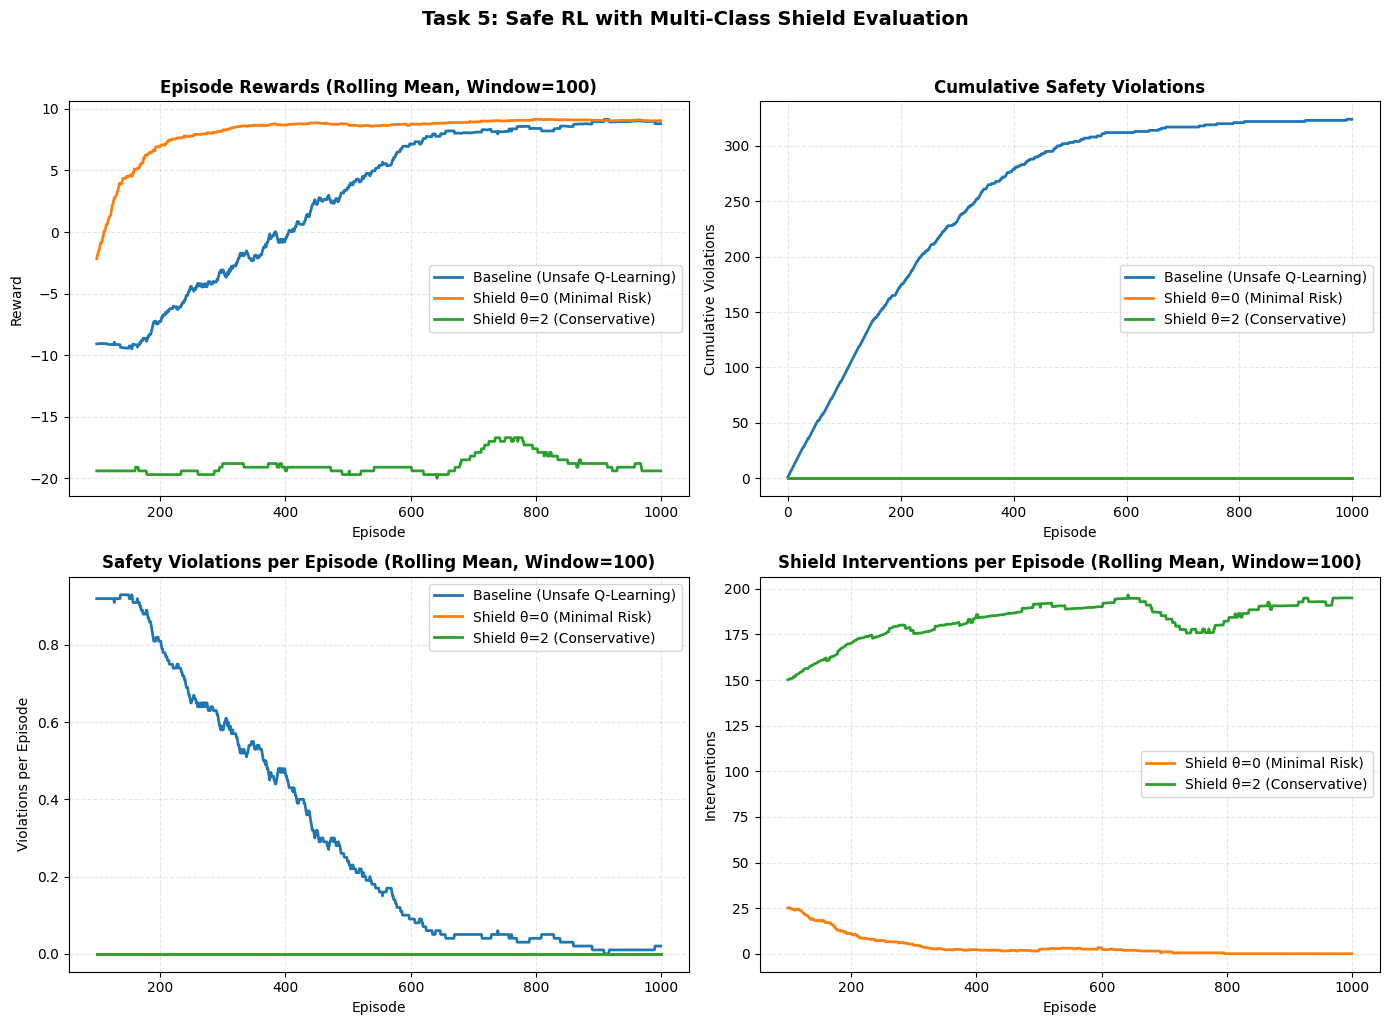


PERFORMANCE SUMMARY (Last 100 Episodes)

📊 BASELINE (Unsafe Q-Learning):
   • Average Reward: 8.80
   • Total Violations: 2

🛡️ SHIELD θ=0 (Minimal Risk Threshold):
   • Average Reward: 9.04
   • Total Violations: 0
   • Total Interventions: 1

🔒 SHIELD θ=2 (Conservative Shield):
   • Average Reward: -19.40
   • Total Violations: 0
   • Total Interventions: 19505

KEY INSIGHTS:

✅ Shield θ=0 vs Baseline:
   • Reward improvement: 2.8%
   • Violations eliminated: 2
   • Minimal interventions: Only 1 actions corrected

⚠️ Shield θ=2 Trade-offs:
   • Safety: Perfect (0 violations)
   • Cost: Excessive interventions (19505)
   • Performance: Severely degraded (reward: -19.40)


✅ Evaluation complete! Ready for discussion session.


In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Task 5: Evaluation - Load and Visualize Safe RL Results

def load_results():
    """Load saved training results from pickle file"""
    with open('data/task5_results.pkl', 'rb') as f:
        data = pickle.load(f)
    return data['results'], data['summary']

def rolling_mean_right(x, w=100):
    """Calculate rolling mean with right alignment"""
    x = np.asarray(x, float)
    w = max(1, min(w, x.size))
    c = np.cumsum(np.insert(x, 0, 0.0))
    vals = (c[w:] - c[:-w]) / w
    return np.concatenate([np.full(w - 1, np.nan), vals])

def plot_results(results, episodes=1000):
    """Generate comprehensive evaluation plots"""

    # Prepare data
    xs = np.arange(episodes)

    # Extract data for plotting
    rewards = {
        'baseline': results['baseline']['rewards'],
        'shield_theta_0': results['shield_theta_0']['rewards'],
        'shield_theta_2': results['shield_theta_2']['rewards'],
    }

    violations = {
        'baseline': results['baseline']['violations'],
        'shield_theta_0': results['shield_theta_0']['violations'],
        'shield_theta_2': results['shield_theta_2']['violations'],
    }

    interventions = {
        'shield_theta_0': results['shield_theta_0']['interventions'],
        'shield_theta_2': results['shield_theta_2']['interventions'],
    }

    # Define plot styling
    names = ['baseline', 'shield_theta_0', 'shield_theta_2']
    colors = {
        'baseline': '#1f77b4',
        'shield_theta_0': '#ff7f0e',
        'shield_theta_2': '#2ca02c'
    }
    labels = {
        'baseline': 'Baseline (Unsafe Q-Learning)',
        'shield_theta_0': 'Shield θ=0 (Minimal Risk)',
        'shield_theta_2': 'Shield θ=2 (Conservative)'
    }

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Episode Rewards (rolling mean)
    for k in names:
        axes[0, 0].plot(xs, rolling_mean_right(rewards[k], 100),
                       label=labels[k], color=colors[k], linewidth=2)
    axes[0, 0].set_title('Episode Rewards (Rolling Mean, Window=100)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(alpha=0.3, linestyle='--')
    axes[0, 0].legend(loc='best')

    # Plot 2: Cumulative Safety Violations
    for k in names:
        axes[0, 1].plot(xs, np.cumsum(violations[k]),
                       label=labels[k], color=colors[k], linewidth=2)
    axes[0, 1].set_title('Cumulative Safety Violations', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Cumulative Violations')
    axes[0, 1].grid(alpha=0.3, linestyle='--')
    axes[0, 1].legend(loc='best')

    # Plot 3: Violations per Episode (rolling mean)
    for k in names:
        axes[1, 0].plot(xs, rolling_mean_right(violations[k], 100),
                       label=labels[k], color=colors[k], linewidth=2)
    axes[1, 0].set_title('Safety Violations per Episode (Rolling Mean, Window=100)',
                        fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Violations per Episode')
    axes[1, 0].grid(alpha=0.3, linestyle='--')
    axes[1, 0].legend(loc='best')

    # Plot 4: Shield Interventions per Episode (rolling mean)
    for k in ['shield_theta_0', 'shield_theta_2']:
        axes[1, 1].plot(xs, rolling_mean_right(interventions[k], 100),
                       label=labels[k], color=colors[k], linewidth=2)
    axes[1, 1].set_title('Shield Interventions per Episode (Rolling Mean, Window=100)',
                        fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Interventions')
    axes[1, 1].grid(alpha=0.3, linestyle='--')
    axes[1, 1].legend(loc='best')

    plt.suptitle('Task 5: Safe RL with Multi-Class Shield Evaluation',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def print_summary(summary):
    """Print formatted summary statistics"""
    print('\n' + '='*60)
    print('PERFORMANCE SUMMARY (Last 100 Episodes)')
    print('='*60)

    # Baseline results
    print('\n📊 BASELINE (Unsafe Q-Learning):')
    print(f"   • Average Reward: {summary['baseline']['avg_reward_last100']:.2f}")
    print(f"   • Total Violations: {summary['baseline']['violations_last100']}")

    # Shield θ=0 results
    print('\n🛡️ SHIELD θ=0 (Minimal Risk Threshold):')
    print(f"   • Average Reward: {summary['shield_theta_0']['avg_reward_last100']:.2f}")
    print(f"   • Total Violations: {summary['shield_theta_0']['violations_last100']}")
    print(f"   • Total Interventions: {summary['shield_theta_0']['interventions_last100']}")

    # Shield θ=2 results
    print('\n🔒 SHIELD θ=2 (Conservative Shield):')
    print(f"   • Average Reward: {summary['shield_theta_2']['avg_reward_last100']:.2f}")
    print(f"   • Total Violations: {summary['shield_theta_2']['violations_last100']}")
    print(f"   • Total Interventions: {summary['shield_theta_2']['interventions_last100']}")

    # Analysis
    print('\n' + '='*60)
    print('KEY INSIGHTS:')
    print('='*60)

    # Calculate improvements
    reward_improvement_0 = ((summary['shield_theta_0']['avg_reward_last100'] -
                            summary['baseline']['avg_reward_last100']) /
                           abs(summary['baseline']['avg_reward_last100']) * 100)

    violation_reduction = summary['baseline']['violations_last100'] - summary['shield_theta_0']['violations_last100']

    print(f"\n✅ Shield θ=0 vs Baseline:")
    print(f"   • Reward improvement: {reward_improvement_0:.1f}%")
    print(f"   • Violations eliminated: {violation_reduction}")
    print(f"   • Minimal interventions: Only {summary['shield_theta_0']['interventions_last100']} actions corrected")

    print(f"\n⚠️ Shield θ=2 Trade-offs:")
    print(f"   • Safety: Perfect (0 violations)")
    print(f"   • Cost: Excessive interventions ({summary['shield_theta_2']['interventions_last100']})")
    print(f"   • Performance: Severely degraded (reward: {summary['shield_theta_2']['avg_reward_last100']:.2f})")

    print('\n' + '='*60)

# Main execution
if __name__ == "__main__":
    try:
        # Load saved results
        print("Loading trained model results from 'data/task5_results.pkl'...")
        results, summary = load_results()

        # Generate evaluation plots
        print("Generating evaluation plots...")
        plot_results(results, episodes=1000)

        # Print performance summary
        print_summary(summary)

    except FileNotFoundError:
        print("❌ Error: Cannot find 'data/task5_results.pkl'")
        print("   Please run the training script first to generate the results file.")
    except Exception as e:
        print(f"❌ Error loading results: {e}")